<a href="https://colab.research.google.com/github/malikbaqi12/GA-Attainment-Anlaysis-SP26/blob/main/GA_Attainment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GA Attainment - Data Entry, Analysis & Visualization (Google Colab)

Run this notebook in **Google Colab**: https://colab.research.google.com →
File → Upload notebook → select this `.ipynb` file. Then run the cells top
to bottom (Runtime → Run all, or Shift+Enter cell by cell).

It lets you:
- upload the GA Attainment master workbook (`.xlsx`)
- enter CLO scores through a simple guided prompt instead of hunting for the
  right column by hand
- run GA (Graduate Attribute) attainment analysis and charts
- download the updated workbook back to your computer

**How the workbook is structured:** each batch sheet (e.g. `AI-SP-26`) has one
row per student and hundreds of columns, one block per course, split into
CLOs (Course Learning Outcomes). The header block always follows the same
layout relative to the `Student Name` cell:

| Offset from header row | Contents |
|---|---|
| 0 | `Student Name` |
| +1 | Course name (merged across its columns) |
| +2 | CLO label (`CLO 1`, `CLO 2`, ...) |
| +3 | Component (`Theory` / `Lab`), optional |
| +4 | GA label (`GA1`, `GA2`, ...) the CLO feeds into |
| +5 | first row of student data |

Roll number sits one column to the left of the `Student Name` column.


## 0. Setup (Colab only needs openpyxl - the rest ship pre-installed)

In [1]:
!pip install -q openpyxl


## 1. Upload the workbook

Run this cell, then click **Choose Files** and pick your `.xlsx` file.


In [2]:
import io
import re
from datetime import datetime

import openpyxl
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    uploaded = files.upload()
    FILE_PATH = list(uploaded.keys())[0]
else:
    # Running outside Colab (e.g. local Jupyter) - set the path manually
    FILE_PATH = "GA_Attainment_Spring_2026.xlsx"

print("Using file:", FILE_PATH)


Saving GA_Attainment_Spring_2026.xlsx.xlsx to GA_Attainment_Spring_2026.xlsx (1).xlsx
Using file: GA_Attainment_Spring_2026.xlsx (1).xlsx


## 2. Core parsing functions

In [3]:
def norm(s):
    if s is None:
        return ""
    return re.sub(r"\s+", " ", str(s).strip().lower())


def norm_clo(s):
    return norm(s).replace(" ", "")


def ffill(vals):
    out, last = [], None
    for v in vals:
        if v is not None:
            last = v
        out.append(last)
    return out


def find_header_anchor(ws):
    """Locate the row/column of the 'Student Name' header cell."""
    for row in ws.iter_rows(min_row=1, max_row=10):
        for cell in row:
            if cell.value and norm(cell.value) == "student name":
                return cell.row, cell.column
    return None


In [4]:
def build_maps(ws):
    """
    Returns:
      col_map:  dict (course_norm, component_norm, clo_norm) -> column index
      col_meta: dict column index -> {course, component, clo, ga}
      row_map:  dict roll_norm -> {row, roll, name}
    """
    anchor = find_header_anchor(ws)
    if anchor is None:
        return None
    name_row, name_col = anchor
    course_row, clo_row, comp_row, ga_row = (
        name_row + 1, name_row + 2, name_row + 3, name_row + 4,
    )
    data_start_row = name_row + 5
    roll_col = name_col - 1
    max_col, max_row = ws.max_column, ws.max_row

    course_vals = [ws.cell(row=course_row, column=c).value for c in range(1, max_col + 1)]
    clo_vals    = [ws.cell(row=clo_row,    column=c).value for c in range(1, max_col + 1)]
    comp_vals   = [ws.cell(row=comp_row,   column=c).value for c in range(1, max_col + 1)]
    ga_vals     = [ws.cell(row=ga_row,     column=c).value for c in range(1, max_col + 1)]

    course_ff = ffill(course_vals)
    comp_ff, last_comp, last_course = [], None, None
    for i in range(len(course_ff)):
        if course_ff[i] != last_course:
            last_comp = None
            last_course = course_ff[i]
        if comp_vals[i] is not None:
            last_comp = comp_vals[i]
        comp_ff.append(last_comp)

    col_map, col_meta = {}, {}
    for i in range(len(clo_vals)):
        col_idx = i + 1
        if clo_vals[i] is None or course_ff[i] is None:
            continue
        key = (norm(course_ff[i]), norm(comp_ff[i]) or "", norm_clo(clo_vals[i]))
        col_map.setdefault(key, col_idx)
        col_meta[col_idx] = dict(course=course_ff[i], component=comp_ff[i] or "",
                                  clo=clo_vals[i], ga=ga_vals[i])

    row_map = {}
    for r in range(data_start_row, max_row + 1):
        roll = ws.cell(row=r, column=roll_col).value
        name = ws.cell(row=r, column=name_col).value
        if roll:
            row_map[norm(roll)] = dict(row=r, roll=roll, name=name)

    return dict(col_map=col_map, col_meta=col_meta, row_map=row_map,
                name_row=name_row, name_col=name_col, roll_col=roll_col,
                data_start_row=data_start_row)


## 3. Load the workbook and build maps for every batch sheet

In [5]:
# Safety check - make sure section 1 (upload) actually ran first
if "FILE_PATH" not in dir():
    raise RuntimeError(
        "FILE_PATH is not defined. Run the upload cell in section 1 first, "
        "then run this cell."
    )

try:
    wb = openpyxl.load_workbook(FILE_PATH, data_only=False)
except FileNotFoundError:
    raise RuntimeError(
        f"Could not find '{FILE_PATH}'. If you are in Colab, re-run the "
        "upload cell in section 1 and pick your .xlsx file again."
    )
except Exception as e:
    raise RuntimeError(
        f"Could not open '{FILE_PATH}' as an Excel workbook ({e}). "
        "Make sure you uploaded the correct .xlsx file (not a .csv or a "
        "renamed/corrupted file)."
    )

batch_sheets = [s for s in wb.sheetnames if s.lower() != "sheet1"]
if not batch_sheets:
    raise RuntimeError(
        "No batch sheets found (only 'Sheet1' or nothing at all). "
        f"Sheets in this file: {wb.sheetnames}"
    )

maps_cache = {}
unparsed_sheets = []
for s in batch_sheets:
    m = build_maps(wb[s])
    if m is not None:
        maps_cache[s] = m
    else:
        unparsed_sheets.append(s)

print(f"Parsed {len(maps_cache)} of {len(batch_sheets)} batch sheet(s):")
for s, m in maps_cache.items():
    print(f"  {s}: {len(m['col_map'])} course/CLO columns, {len(m['row_map'])} students")

if unparsed_sheets:
    print(
        "\nCould not find a 'Student Name' header in these sheet(s), so they "
        "were skipped:", unparsed_sheets
    )


Parsed 10 of 10 batch sheet(s):
  AI-SP-26: 214 course/CLO columns, 53 students
  AI-FA-25: 216 course/CLO columns, 20 students
  AI-SP-25: 213 course/CLO columns, 24 students
  AI-FA-24: 211 course/CLO columns, 39 students
  AI-SP-24: 30 course/CLO columns, 29 students
  AI-FA-23: 54 course/CLO columns, 27 students
  AI-SP-23: 102 course/CLO columns, 14 students
  AI-FA-22: 162 course/CLO columns, 11 students
  AI-SP-22: 50 course/CLO columns, 7 students
  AI-FA-21: 48 course/CLO columns, 3 students


## 4. Automated data entry

`apply_entries` takes a list of dicts (one per score) and writes each value
into the correct cell, reporting anything that couldn't be matched instead of
failing silently.


In [6]:
def apply_entries(wb, maps_cache, entries):
    """
    entries: list of dicts with keys batch, roll, course, component, clo, score
    Returns (applied_count, skipped_list)
    """
    applied = 0
    skipped = []
    for entry in entries:
        batch = entry["batch"]
        maps = maps_cache.get(batch)
        if maps is None:
            skipped.append((entry, "unknown batch sheet"))
            continue
        ws = wb[batch]
        key = (norm(entry["course"]), norm(entry.get("component", "")) or "", norm_clo(entry["clo"]))
        col_idx = maps["col_map"].get(key)
        rinfo = maps["row_map"].get(norm(entry["roll"]))
        if col_idx is None:
            skipped.append((entry, "course/component/CLO not found"))
            continue
        if rinfo is None:
            skipped.append((entry, "roll no not found in this batch sheet"))
            continue
        ws.cell(row=rinfo["row"], column=col_idx).value = entry["score"]
        applied += 1
    return applied, skipped


### 4a. Option A - guided interactive entry

Run this cell and answer the prompts one score at a time. Type nothing at the
Batch prompt to stop. Works fine in Colab's normal `input()` prompts.


In [7]:
def guided_entry_session(wb, maps_cache):
    entries = []
    batch_list = list(maps_cache.keys())
    print("Available batches:", ", ".join(batch_list))
    while True:
        batch = input("Batch (blank to stop): ").strip()
        if not batch:
            break
        if batch not in maps_cache:
            print("  Unknown batch, try again.")
            continue
        maps = maps_cache[batch]

        roll = input("  Roll No (or type done to finish this batch): ").strip()
        if roll.lower() == "done":
            continue
        rinfo = maps["row_map"].get(norm(roll))
        if rinfo is None:
            print("  Roll No not found in this batch, skipping.")
            continue
        print("  Student:", rinfo["name"])

        course = input("  Course (exact name as in the sheet): ").strip()
        component = input("  Component (Theory / Lab / blank): ").strip()
        clo = input("  CLO (e.g. CLO 1): ").strip()
        score_raw = input("  Score: ").strip()
        try:
            score = float(score_raw)
        except ValueError:
            print("  Not a number, skipping.")
            continue

        entries.append(dict(batch=batch, roll=roll, course=course,
                             component=component, clo=clo, score=score))
        print("  Queued.")
    return entries


# Uncomment to run an interactive session:
# new_entries = guided_entry_session(wb, maps_cache)
# applied, skipped = apply_entries(wb, maps_cache, new_entries)
# print(f"Applied: {applied}, Skipped: {len(skipped)}")
# for s in skipped:
#     print(" -", s)


### 4b. Option B - list of entries in code

Faster if you already have the scores in front of you: edit the list below
and run the cell.


In [8]:
example_entries = [
    # dict(batch="AI-SP-26", roll="052-26-128002", course="Applied Physics",
    #      component="Theory", clo="CLO 2", score=91.5),
]

applied, skipped = apply_entries(wb, maps_cache, example_entries)
print(f"Applied: {applied}, Skipped: {len(skipped)}")
for s in skipped:
    print(" -", s)


Applied: 0, Skipped: 0


## 5. Save the updated workbook (and download it if running in Colab)

In [9]:
OUT_PATH = "GA_Attainment_updated.xlsx"
wb.save(OUT_PATH)
print("Saved", OUT_PATH)

if IN_COLAB:
    files.download(OUT_PATH)


Saved GA_Attainment_updated.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 6. Build a tidy (long-format) dataframe of every score in the workbook

In [10]:
def build_tidy_dataframe(wb, batch_sheets, maps_cache):
    records = []
    for sheet_name in batch_sheets:
        maps = maps_cache.get(sheet_name)
        if maps is None:
            continue
        ws = wb[sheet_name]
        for col_idx, meta in maps["col_meta"].items():
            for rinfo in maps["row_map"].values():
                val = ws.cell(row=rinfo["row"], column=col_idx).value
                if isinstance(val, (int, float)):
                    records.append(dict(
                        batch=sheet_name, roll=rinfo["roll"], name=rinfo["name"],
                        course=meta["course"], component=meta["component"],
                        clo=meta["clo"], ga=meta["ga"], score=val,
                    ))
    return pd.DataFrame(records)


df = build_tidy_dataframe(wb, batch_sheets, maps_cache)
print(df.shape)
df.head()


(5132, 8)


,batch,roll,name,course,component,clo,ga,score
0,AI-SP-26,052-26-128002,Muhammad Umar Jalal,Application of information & Communication Tec...,Theory,CLO 1,GA1,59.05
1,AI-SP-26,052-26-128003,Iftikhar Ahmed,Application of information & Communication Tec...,Theory,CLO 1,GA1,53.57
2,AI-SP-26,052-26-128005,Shah nawaz,Application of information & Communication Tec...,Theory,CLO 1,GA1,83.81
3,AI-SP-26,052-26-128006,Hamid Safeer,Application of information & Communication Tec...,Theory,CLO 1,GA1,77.38
4,AI-SP-26,052-26-128008,Aazib Ilyas,Application of information & Communication Tec...,Theory,CLO 1,GA1,83.33


## 7. GA attainment per student (recomputed cleanly from raw CLO scores)

In [11]:
df["ga_norm"] = df["ga"].astype(str).str.replace(" ", "").str.upper()
df_ga = df[df["ga_norm"].str.match(r"^GA\d+$")]

attainment = (
    df_ga.groupby(["batch", "roll", "name", "ga_norm"])["score"]
    .mean()
    .reset_index()
    .rename(columns={"score": "attainment_pct"})
)
attainment.head(10)


,batch,roll,name,ga_norm,attainment_pct
0,AI-FA-21,Ck-fa21-110508,Muhammad Abbas,GA1,70.192000
1,AI-FA-21,Ck-fa21-110508,Muhammad Abbas,GA2,53.015333
2,AI-FA-21,Ck-fa21-110508,Muhammad Abbas,GA3,49.037755
3,AI-FA-21,Ck-fa21-110508,Muhammad Abbas,GA4,58.888889
4,AI-FA-21,Ck-fa21-110511,Shahzaib,GA1,78.624000
5,AI-FA-21,Ck-fa21-110511,Shahzaib,GA2,76.081111
6,AI-FA-21,Ck-fa21-110511,Shahzaib,GA3,73.130340
7,AI-FA-21,Ck-fa21-110511,Shahzaib,GA4,74.583333
8,AI-FA-21,ck-fa21-110510,Ahmad Raza,GA1,77.224000
9,AI-FA-21,ck-fa21-110510,Ahmad Raza,GA2,80.478667


## 8. Visualization: average GA attainment per batch

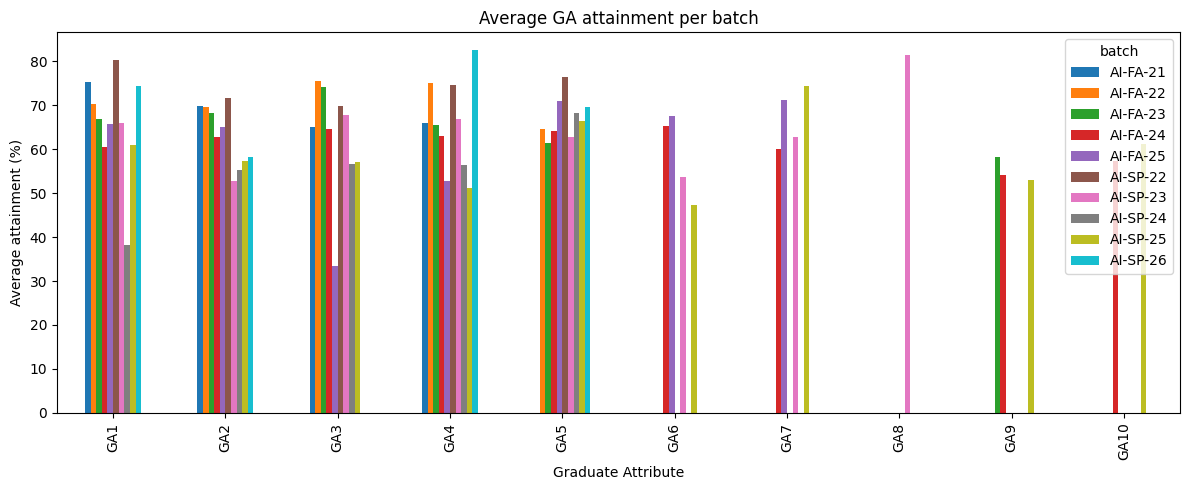

In [12]:
ga_order = sorted(attainment["ga_norm"].unique(), key=lambda x: int(x[2:]))
ga_batch_avg = (
    attainment.groupby(["batch", "ga_norm"])["attainment_pct"].mean().reset_index()
)
pivot = ga_batch_avg.pivot(index="ga_norm", columns="batch", values="attainment_pct").reindex(ga_order)

ax = pivot.plot(kind="bar", figsize=(12, 5))
ax.set_xlabel("Graduate Attribute")
ax.set_ylabel("Average attainment (%)")
ax.set_title("Average GA attainment per batch")
plt.tight_layout()
plt.show()


## 9. Visualization: GA attainment heatmap (batch x GA)

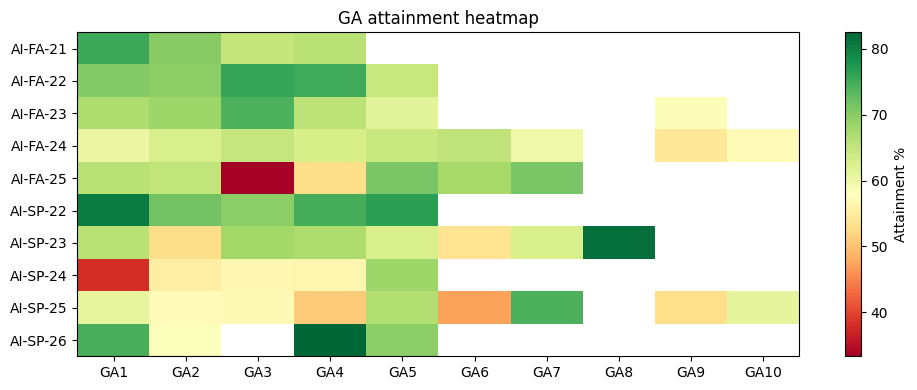

In [13]:
heat = ga_batch_avg.pivot(index="batch", columns="ga_norm", values="attainment_pct")
heat = heat[[c for c in ga_order if c in heat.columns]]

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(heat.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
fig.colorbar(im, ax=ax, label="Attainment %")
ax.set_title("GA attainment heatmap")
plt.tight_layout()
plt.show()


## 10. Visualization: course-level average scores for one batch

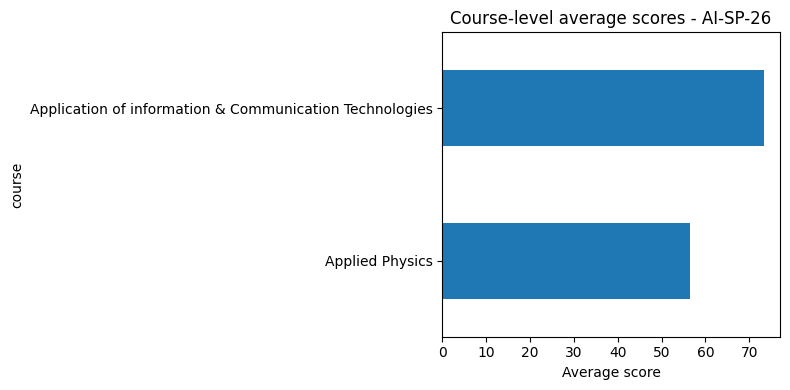

In [14]:
BATCH_TO_VIEW = batch_sheets[0]  # change as needed

course_avg = (
    df[df["batch"] == BATCH_TO_VIEW]
    .groupby("course")["score"].mean()
    .sort_values()
)

ax = course_avg.plot(kind="barh", figsize=(8, max(4, 0.3 * len(course_avg))))
ax.set_xlabel("Average score")
ax.set_title(f"Course-level average scores - {BATCH_TO_VIEW}")
plt.tight_layout()
plt.show()


## 11. Students below a chosen attainment threshold

In [15]:
THRESHOLD = 50

low_attainment = attainment[attainment["attainment_pct"] < THRESHOLD].sort_values("attainment_pct")
low_attainment


,batch,roll,name,ga_norm,attainment_pct
1400,AI-SP-26,052-SP26-28198,Ali,GA5,0.000
1396,AI-SP-26,052-26-128267,Umm-e- Farwa,GA5,0.000
1392,AI-SP-26,052-26-128247,Abdul Rahman,GA5,0.000
1388,AI-SP-26,052-26-128221,Talha Riaz,GA5,0.000
1384,AI-SP-26,052-26-128219,Tasawar KHAN,GA5,0.000
...,...,...,...,...,...
119,AI-FA-23,052-FA23-23141,Syed Haider Ali,GA3,49.466
745,AI-SP-23,052-sp23-22033,Saad Mehmood Abbasi,GA2,49.660
295,AI-FA-24,052-24-125180,Talha Arif,GA2,49.750
151,AI-FA-23,052-FA23-23345,Rakhiyal Shah,GA5,49.785


## 12. Export

Save the tidy dataset or the attainment summary as CSV. In Colab these download
automatically; elsewhere they're written to the working directory.


In [16]:
df.to_csv("ga_scores_tidy.csv", index=False)
attainment.to_csv("ga_attainment_summary.csv", index=False)
print("Saved ga_scores_tidy.csv and ga_attainment_summary.csv")

if IN_COLAB:
    files.download("ga_scores_tidy.csv")
    files.download("ga_attainment_summary.csv")


Saved ga_scores_tidy.csv and ga_attainment_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>